# Import relevant libraries

In [2]:
#!pip install matplotlib pandas scikit-learn
#!pip install --upgrade pip
#!pip install statsmodels

In [3]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

from math import sin, cos, sqrt, atan2, radians
import numpy as np
import pandas as pd
import random
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (auc, classification_report, roc_auc_score, accuracy_score,
                             f1_score, log_loss, roc_curve, confusion_matrix, precision_score, recall_score)
import statsmodels.formula.api as smf

np.random.seed(0)

#Load the Data 

In [4]:
tournament_Data = pd.read_csv('https://raw.githubusercontent.com/SethiDeepika/AIML/main/NCAA_Tourney_2002_2025.csv')
tournament_Data.head()
#tournament_TestData = pd.read_csv('https://raw.githubusercontent.com/SethiDeepika/AIML/main/NCAA_Tourney_2002_2025.csv').query("season==2019").reset_index(drop=True)
#tournament_TestData.head()

,team1_id,team1_score,team2_id,team2_score,WLoc,num_ot,team1_position,team2_position,team1_seed,team2_seed,...,team1_adjoe,team1_de,team1_adjde,team2_tempo,team2_adjtempo,team2_oe,team2_adjoe,team2_de,team2_adjde,game_id
0,1314,81.0,1181,77.0,N,0.0,W08,X02,8,2,...,113.035,100.974,96.9911,68.2765,67.4185,117.1520,119.3570,98.2346,95.6444,2022-1314-1181
1,1242,81.0,1437,65.0,N,0.0,Y01,Z02,1,2,...,119.388,97.191,93.9009,64.1915,62.5758,112.8450,117.9210,97.6798,93.8099,2022-1242-1437
2,1242,72.0,1314,69.0,N,0.0,Y01,W08,1,8,...,119.388,97.191,93.9009,70.2181,70.1745,109.4160,113.0350,100.9740,96.9911,2022-1242-1314
3,1242,76.0,1274,50.0,N,0.0,Y01,Y10,1,10,...,119.388,97.191,93.9009,67.5221,67.3101,110.3680,114.7570,104.9830,102.1320,2022-1242-1274
4,1314,69.0,1389,49.0,N,0.0,W08,W15,8,15,...,113.035,100.974,96.9911,67.0262,65.9923,98.7557,98.7475,92.3289,94.4745,2022-1314-1389


In [5]:
# The data has team1 as the winner. We need to create balanced training data
# by also including the reverse matchups (team2 vs team1)
print("\nPreparing training data...")



Preparing training data...


In [ ]:
df_winner = tournament_Data.copy()
df_winner['target'] = 1  # team1 wins
df_loser = tournament_Data.copy()
df_loser['target'] = 0  # team2 loses

team1_cols = [c for c in tournament_Data.columns if c.startswith('team1_')]
team2_cols = [c for c in tournament_Data.columns if c.startswith('team2_')]


# Put Team 2 data into Team 1's columns
df_loser[team1_cols] = tournament_Data[team2_cols].values

# Put Team 1 data into Team 2's columns
df_loser[team2_cols] = tournament_Data[team1_cols].values

# Feature engineering
stat_cols_team1 = [
    'team1_fg2pct', 'team1_fg3pct', 'team1_ftpct', 'team1_blockpct',
    'team1_oppfg2pct', 'team1_oppfg3pct', 'team1_arate', 'team1_opparate',
    'team1_stlrate', 'team1_oppstlrate', 'team1_adjoe', 'team1_adjde'
]

stat_cols_team2 = [
    'team2_fg2pct', 'team2_fg3pct', 'team2_ftpct', 'team2_blockpct',
    'team2_oppfg2pct', 'team2_oppfg3pct', 'team2_arate', 'team2_opparate',
    'team2_stlrate', 'team2_oppstlrate', 'team2_adjoe', 'team2_adjde'
]

df_combined = pd.concat([df_winner, df_loser], axis=0).reset_index(drop=True)
df_combined = df_combined.sort_values(by=['game_id']).reset_index(drop=True)
feature_names = []

for t1, t2 in zip(stat_cols_team1, stat_cols_team2):
    base_name = t1.replace('team1_', '')
    df_combined[f'diff_{base_name}'] = df_combined[t1] - df_combined[t2]
    feature_names.append(f'diff_{base_name}')

# Seed difference
df_combined['seed_diff'] = df_combined['team2_seed'] - df_combined['team1_seed']
feature_names.append('seed_diff')

# Net efficiency difference
df_combined['team1_net_eff'] = df_combined['team1_adjoe'] - df_combined['team1_adjde']
df_combined['team2_net_eff'] = df_combined['team2_adjoe'] - df_combined['team2_adjde']
df_combined['diff_net_eff'] = df_combined['team1_net_eff'] - df_combined['team2_net_eff']
feature_names.append('diff_net_eff')



df_combined.columns



Index(['team1_id', 'team1_score', 'team2_id', 'team2_score', 'WLoc', 'num_ot',
       'team1_position', 'team2_position', 'team1_seed', 'team2_seed',
       'strongseed', 'weakseed', 'team1_region', 'team2_region', 'slot',
       'team1_teamname', 'team2_teamname', 'season', 'host', 'host_lat',
       'host_long', 'team1_lat', 'team1_long', 'team2_lat', 'team2_long',
       'team1_fg2pct', 'team1_fg3pct', 'team1_ftpct', 'team1_blockpct',
       'team1_oppfg2pct', 'team1_oppfg3pct', 'team1_oppftpct',
       'team1_oppblockpct', 'team1_f3grate', 'team1_oppf3grate', 'team1_arate',
       'team1_opparate', 'team1_stlrate', 'team1_oppstlrate', 'team2_fg2pct',
       'team2_fg3pct', 'team2_ftpct', 'team2_blockpct', 'team2_oppfg2pct',
       'team2_oppfg3pct', 'team2_oppftpct', 'team2_oppblockpct',
       'team2_f3grate', 'team2_oppf3grate', 'team2_arate', 'team2_opparate',
       'team2_stlrate', 'team2_oppstlrate', 'team1_tempo', 'team1_adjtempo',
       'team1_oe', 'team1_adjoe', 'team1_de

In [ ]:
#Feature Engineering Using Claude

# ===== 1. TEMPO FEATURES =====
df_combined['diff_tempo'] = df_combined['team1_tempo'] - df_combined['team2_tempo']
df_combined['diff_adjtempo'] = df_combined['team1_adjtempo'] - df_combined['team2_adjtempo']
feature_names.extend(['diff_tempo', 'diff_adjtempo'])

# ===== 2. UPSET INDICATORS =====
df_combined['upset_potential'] = ((df_combined['seed_diff'] < 0) & (df_combined['diff_net_eff'] > 0)).astype(int)
df_combined['seed_diff_sq'] = df_combined['seed_diff'] ** 2
feature_names.extend(['upset_potential', 'seed_diff_sq'])

# ===== 3. SHOOTING EFFICIENCY =====
df_combined['team1_overall_fg'] = df_combined['team1_fg2pct'] * 0.6 + df_combined['team1_fg3pct'] * 0.4
df_combined['team2_overall_fg'] = df_combined['team2_fg2pct'] * 0.6 + df_combined['team2_fg3pct'] * 0.4
df_combined['diff_overall_fg'] = df_combined['team1_overall_fg'] - df_combined['team2_overall_fg']
feature_names.append('diff_overall_fg')

# ===== 4. DEFENSIVE PRESSURE =====
df_combined['team1_def_pressure'] = df_combined['team1_stlrate'] + df_combined['team1_blockpct']
df_combined['team2_def_pressure'] = df_combined['team2_stlrate'] + df_combined['team2_blockpct']
df_combined['diff_def_pressure'] = df_combined['team1_def_pressure'] - df_combined['team2_def_pressure']
feature_names.append('diff_def_pressure')

# ===== 5. TURNOVER MARGIN =====
df_combined['team1_to_margin'] = df_combined['team1_stlrate'] - df_combined['team1_oppstlrate']
df_combined['team2_to_margin'] = df_combined['team2_stlrate'] - df_combined['team2_oppstlrate']
df_combined['diff_to_margin'] = df_combined['team1_to_margin'] - df_combined['team2_to_margin']
feature_names.append('diff_to_margin')

# ===== 6. LUCK (EFF VS SEED) =====
seed_to_eff = {1:28, 2:24, 3:21, 4:18, 5:16, 6:14, 7:12, 8:10, 9:8, 10:6, 11:5, 12:4, 13:2, 14:0, 15:-2, 16:-5}
df_combined['team1_eff_vs_seed'] = df_combined['team1_net_eff'] - df_combined['team1_seed'].map(seed_to_eff)
df_combined['team2_eff_vs_seed'] = df_combined['team2_net_eff'] - df_combined['team2_seed'].map(seed_to_eff)
df_combined['diff_eff_vs_seed'] = df_combined['team1_eff_vs_seed'] - df_combined['team2_eff_vs_seed']
feature_names.append('diff_eff_vs_seed')

# ===== 7. MATCHUP ADVANTAGE =====
df_combined['matchup_advantage'] = (df_combined['team1_adjoe'] - df_combined['team2_adjde']) - (df_combined['team2_adjoe'] - df_combined['team1_adjde'])
feature_names.append('matchup_advantage')

# ===== 8. TEMPO MISMATCH =====
df_combined['tempo_mismatch'] = abs(df_combined['team1_tempo'] - df_combined['team2_tempo'])
feature_names.append('tempo_mismatch')

df_combined

,team1_id,team1_score,team2_id,team2_score,WLoc,num_ot,team1_position,team2_position,team1_seed,team2_seed,...,team2_def_pressure,diff_def_pressure,team1_to_margin,team2_to_margin,diff_to_margin,team1_eff_vs_seed,team2_eff_vs_seed,diff_eff_vs_seed,matchup_advantage,tempo_mismatch
0,1194,78.0,1104,86.0,N,0.0,Y15,Y02,15,2,...,8.1521,0.1632,0.0206,0.0172,0.0034,-1.0594,-6.3816,5.3222,-8.5792,1.3721
1,1104,86.0,1194,78.0,N,0.0,Y02,Y15,2,15,...,8.3153,-0.1632,0.0172,0.0206,-0.0034,-6.3816,-1.0594,-5.3222,8.5792,1.3721
2,1112,86.0,1364,81.0,N,0.0,Z03,Z14,3,14,...,8.8053,-1.4706,-0.0004,0.009,-0.0094,-0.5385,7.783,-8.3215,11.1901,10.9117
3,1364,81.0,1112,86.0,N,0.0,Z14,Z03,14,3,...,7.3347,1.4706,0.009,-0.0004,0.0094,7.783,-0.5385,8.3215,-11.1901,10.9117
4,1112,68.0,1461,60.0,N,0.0,Z03,Z11,3,11,...,10.5315,-3.1968,-0.0004,-0.0108,0.0104,-0.5385,4.3769,-4.9154,11.6168,4.529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3023,1417,72.0,1429,47.0,N,0.0,X07,X10,7,10,...,9.516012,1.108869,0.03662,0.025999,0.010622,9.7623,9.225,0.5373,-14.3073,0.7496
3024,1285,66.0,1458,85.0,N,0.0,W14,W03,14,3,...,6.180186,1.98756,0.007142,0.006637,0.000505,0.384,4.9749,-4.5909,3.1149,1.1587
3025,1458,85.0,1285,66.0,N,0.0,W03,W14,3,14,...,8.167746,-1.98756,0.006637,0.007142,-0.000505,4.9749,0.384,4.5909,-3.1149,1.1587
3026,1400,80.0,1462,86.0,N,0.0,X11a,X11b,11,11,...,7.264909,4.562444,0.007624,0.025461,-0.017837,12.1514,12.197,-0.0456,2.4736,1.0204


In [ ]:


df_training = pd.concat([df_winner, df_loser], axis=0).reset_index(drop=True)
df_training = df_training.sort_values(by=['game_id']).reset_index(drop=True)

#df_training=df_combined[feature_names]
df_training.head()

,team1_id,team1_score,team2_id,team2_score,WLoc,num_ot,team1_position,team2_position,team1_seed,team2_seed,...,team1_de,team1_adjde,team2_tempo,team2_adjtempo,team2_oe,team2_adjoe,team2_de,team2_adjde,game_id,target
0,1194,78.0,1104,86.0,N,0.0,Y15,Y02,15,2,...,98.4183,99.9263,69.8636,69.9001,108.4361,111.4954,95.2313,93.877,2002-1104-1194,0
1,1104,86.0,1194,78.0,N,0.0,Y02,Y15,2,15,...,95.2313,93.877,71.2357,71.2446,100.2897,96.8669,98.4183,99.9263,2002-1104-1194,1
2,1112,86.0,1364,81.0,N,0.0,Z03,Z14,3,14,...,104.0411,96.9262,63.2345,64.7948,105.2163,105.4534,96.0965,97.6704,2002-1112-1364,1
3,1364,81.0,1112,86.0,N,0.0,Z14,Z03,14,3,...,96.0965,97.6704,74.1462,72.8207,111.0077,117.3877,104.0411,96.9262,2002-1112-1364,0
4,1112,68.0,1461,60.0,N,0.0,Z03,Z11,3,11,...,104.0411,96.9262,69.6172,70.4124,105.3654,106.037,97.0568,96.6601,2002-1112-1461,1


In [ ]:
df_training.shape

(3028, 67)

In [8]:
#!pip install tensorflow

In [9]:
# Keras imports
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Sklearn for preprocessing and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

2026-02-15 02:04:26.501444: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [10]:
df_combined
#df_combined[df_combined['season'] != '2019']
df_combined[df_combined['season'] != 2019]

,team1_id,team1_score,team2_id,team2_score,WLoc,num_ot,team1_position,team2_position,team1_seed,team2_seed,...,team2_def_pressure,diff_def_pressure,team1_to_margin,team2_to_margin,diff_to_margin,team1_eff_vs_seed,team2_eff_vs_seed,diff_eff_vs_seed,matchup_advantage,tempo_mismatch
0,1194,78.0,1104,86.0,N,0.0,Y15,Y02,15,2,...,8.1521,0.1632,0.0206,0.0172,0.0034,-1.0594,-6.3816,5.3222,-8.5792,1.3721
1,1104,86.0,1194,78.0,N,0.0,Y02,Y15,2,15,...,8.3153,-0.1632,0.0172,0.0206,-0.0034,-6.3816,-1.0594,-5.3222,8.5792,1.3721
2,1112,86.0,1364,81.0,N,0.0,Z03,Z14,3,14,...,8.8053,-1.4706,-0.0004,0.009,-0.0094,-0.5385,7.783,-8.3215,11.1901,10.9117
3,1364,81.0,1112,86.0,N,0.0,Z14,Z03,14,3,...,7.3347,1.4706,0.009,-0.0004,0.0094,7.783,-0.5385,8.3215,-11.1901,10.9117
4,1112,68.0,1461,60.0,N,0.0,Z03,Z11,3,11,...,10.5315,-3.1968,-0.0004,-0.0108,0.0104,-0.5385,4.3769,-4.9154,11.6168,4.529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3023,1417,72.0,1429,47.0,N,0.0,X07,X10,7,10,...,9.516012,1.108869,0.03662,0.025999,0.010622,9.7623,9.225,0.5373,-14.3073,0.7496
3024,1285,66.0,1458,85.0,N,0.0,W14,W03,14,3,...,6.180186,1.98756,0.007142,0.006637,0.000505,0.384,4.9749,-4.5909,3.1149,1.1587
3025,1458,85.0,1285,66.0,N,0.0,W03,W14,3,14,...,8.167746,-1.98756,0.006637,0.007142,-0.000505,4.9749,0.384,4.5909,-3.1149,1.1587
3026,1400,80.0,1462,86.0,N,0.0,X11a,X11b,11,11,...,7.264909,4.562444,0.007624,0.025461,-0.017837,12.1514,12.197,-0.0456,2.4736,1.0204


In [12]:
df_combined_Train = df_combined[df_combined['season'] != 2019]

num_cols = df_combined_Train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_combined_Train.select_dtypes(include=['object']).columns

df_combined_Train[num_cols] = df_combined_Train[num_cols].fillna(
    df_combined_Train[num_cols].median())

for col in cat_cols:
    df_combined_Train[col] = df_combined_Train[col].fillna(
        df_combined_Train[col].mode()[0])

# Features (X) and Target (y)
X = df_combined_Train[feature_names].values
y = df_combined_Train['target'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (2894, 24)
y shape: (2894,)


/tmp/ipykernel_919/1096858406.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_combined_Train.select_dtypes(include=['object']).columns


In [64]:
scaler = StandardScaler()
import numpy as np

X_train_scaled = scaler.fit_transform(X)

X_train_scaled.shape

(2894, 24)

In [65]:
model = Sequential()

# Input layer + First hidden layer
# input_dim = number of features
model.add(Dense(128, activation='relu', input_dim=X_train_scaled.shape[1]))
model.add(Dropout(0.3))  # Dropout to prevent overfitting

# Second hidden layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

# Third hidden layer
model.add(Dense(128, activation='relu'))

#model.add(Dense(64, activation='relu'))

# Output layer (1 neuron with sigmoid for binary classification)
model.add(Dense(1, activation='sigmoid'))
#model.add(Dense(2, activation='softmax'))

print("✅ Model built!")
model.summary()

✅ Model built!


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,353 (142.00 KB)

 Trainable params: 36,353 (142.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=
    #"rmsprop",
    Adam(learning_rate=0.00001),  # Adam optimizer with default learning rate
    loss='binary_crossentropy',
    #loss = 'sparse_categorical_crossentropy' ,          # Loss function for binary classification
    metrics=['accuracy']                   # Track accuracy during training
)

print("✅ Model compiled!")

✅ Model compiled!


In [67]:
early_stop = EarlyStopping(
    monitor='val_loss',      # Watch validation loss
    patience=10,             # Wait 10 epochs before stopping
    restore_best_weights=True  # Keep the best model
)

print("✅ Early stopping configured")

✅ Early stopping configured


In [ ]:

print("🏋️ Training the model...\n")


history = model.fit(
    X_train_scaled, 
    y,
    epochs=100,              # Maximum epochs (early stopping will likely stop before)
    batch_size=32,           # Process 32 samples at a time
    validation_split=0.3,    # Use 20% of training data for validation
    callbacks=[early_stop],  # Use early stopping
    verbose=1                # Show progress
)


print(f"\n✅ Training complete! Stopped at epoch {len(history.history['loss'])}")
print(history.history)

🏋️ Training the model...

Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5823 - loss: 0.6731 - val_accuracy: 0.6218 - val_loss: 0.6493
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6700 - loss: 0.6197 - val_accuracy: 0.6459 - val_loss: 0.6169
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6855 - loss: 0.5872 - val_accuracy: 0.6632 - val_loss: 0.6018
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6972 - loss: 0.5725 - val_accuracy: 0.6632 - val_loss: 0.6024
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7002 - loss: 0.5619 - val_accuracy: 0.6632 - val_loss: 0.6034
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6955 - loss: 0.5597 - val_accuracy: 0.6736 - val_loss: 0.6046
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6972 - loss: 0.5561 - val_accuracy: 0.6736 - val_loss: 0.6052
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7050 - loss: 0.5535 

In [69]:

df_combined_Test = df_combined[df_combined['season'] == 2019]


# Features (X) and Target (y)
X_test = df_combined_Test[feature_names].values
X_test_scaled = scaler.transform(X_test)
y_test = df_combined_Test['target'].values


#test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print("="*50)
print("📊 TEST SET RESULTS")
print("="*50)
##print(f"Test Accuracy: {test_accuracy:.2%}")
#print(f"Test Loss: {test_loss:.4f}")

y_test

📊 TEST SET RESULTS


array([0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 0])

In [70]:
y_pred_proba = model.predict(X_test_scaled)  # Probabilities#
#y_pred_proba = y_pred_proba[:, 1] 

# 3. Apply your custom 0.6 threshold
y_pred = (y_pred_proba > 0.5).astype(int)

# Classification report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Team2 Wins', 'Team1 Wins']))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

📋 Classification Report:
              precision    recall  f1-score   support

  Team2 Wins       0.72      0.75      0.74        67
  Team1 Wins       0.74      0.72      0.73        67

    accuracy                           0.73       134
   macro avg       0.73      0.73      0.73       134
weighted avg       0.73      0.73      0.73       134



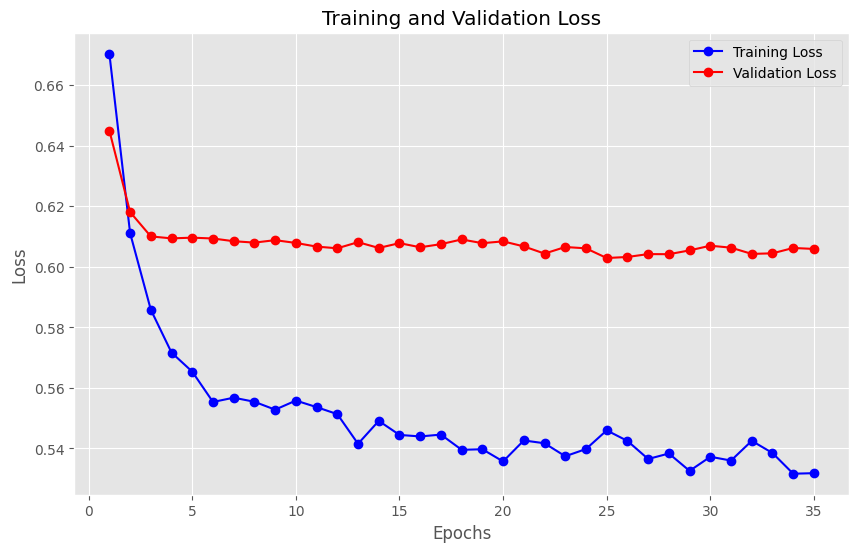

In [62]:
import matplotlib.pyplot as plt

def plot_loss(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    # This ensures the X-axis always matches the number of completed epochs
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(10, 6))
    
    # Use 'epochs' for the X-axis
    plt.plot(epochs, loss, 'bo-', label='Training Loss') 
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss(history)

In [71]:
#y_pred_proba
from sklearn.metrics import log_loss

# Calculate log loss
logloss = log_loss(y_test, y_pred_proba)

print(f"Log Loss: {logloss:.4f}")

Log Loss: 0.5045


#Better Logloss if claude features are not included 


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


                      accuracy       auc   logloss
LogisticRegression    0.716418  0.857652  0.454956
ExtraTrees            0.716418  0.844732  0.483016
SVM_RBF               0.723881  0.844063  0.503547
KNN                   0.694030  0.840053  0.495722
XGBoost               0.694030  0.828692  0.498812
RandomForest          0.708955  0.826242  0.497554
HistGradientBoosting  0.686567  0.802629  0.582145


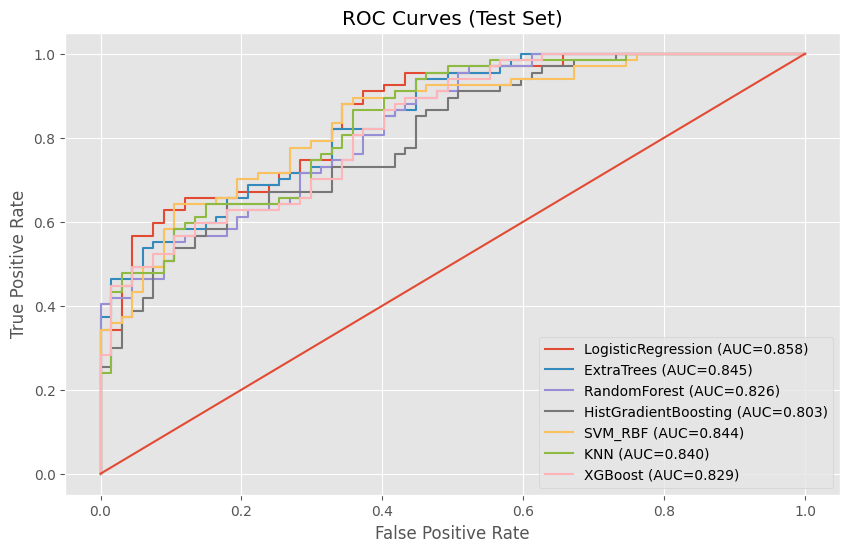

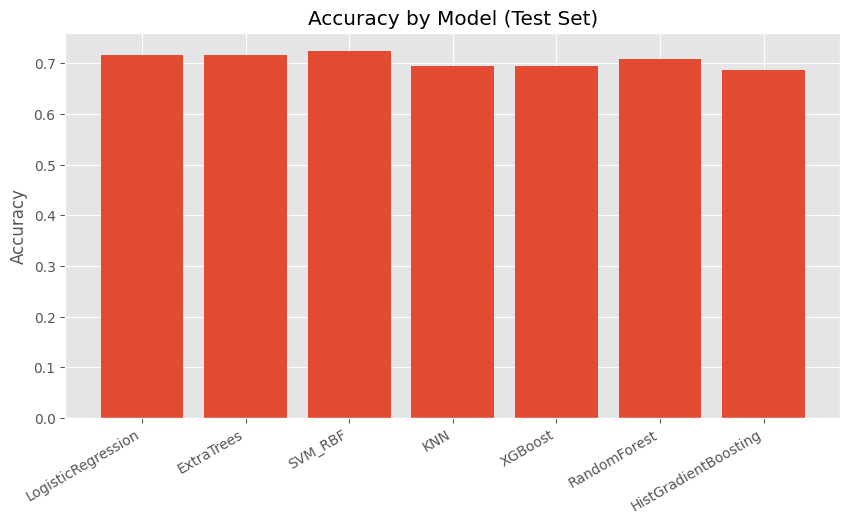

In [46]:
#Other Models
#!pip install xgboost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.impute import SimpleImputer

# Create an imputer (fills NaNs with the mean of the column)
imputer = SimpleImputer(strategy='mean') 

# Apply to your features (assuming X_train_scaled/X_test_scaled came from X_train/X_test)
X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed = imputer.transform(X_test_scaled)

# Update your sparse/dense assignments
Xtr_sparse = X_train_imputed
Xte_sparse = X_test_imputed

def to_dense_if_sparse(M):
    return M.toarray() if hasattr(M, "toarray") else M


Xtr_dense  = to_dense_if_sparse(Xtr_sparse)
Xte_dense  = to_dense_if_sparse(Xte_sparse)

try:
    from xgboost import XGBClassifier
    xgb_ok = True
except Exception as e:
    xgb_ok = False
    print("XGBoost not available. Install with: pip install xgboost")
    print("Import error:", e)

models = {
    "LogisticRegression": LogisticRegression(max_iter=8000, n_jobs=-1),

    "ExtraTrees": ExtraTreesClassifier(n_estimators=1200, random_state=42, n_jobs=-1, min_samples_leaf=2),
    "RandomForest": RandomForestClassifier(n_estimators=800, random_state=42, n_jobs=-1, min_samples_leaf=2),

    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42, max_depth=6, learning_rate=0.06, max_iter=400),

    "SVM_RBF": SVC(probability=True, kernel="rbf", C=2.0, gamma="scale", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=35, weights="distance"),
}

if xgb_ok:
    models["XGBoost"] = XGBClassifier(
        n_estimators=900,
        max_depth=5,
        learning_rate=0.01,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    )

dense_only = {"HistGradientBoosting", "SVM_RBF", "KNN"}

results = {}
roc_lines = {}

for name, model in models.items():
    Xtr = Xtr_dense if name in dense_only else Xtr_sparse
    Xte = Xte_dense if name in dense_only else Xte_sparse

    model.fit(Xtr, y)

    proba = model.predict_proba(Xte)[:, 1]
    pred = (proba >= 0.5).astype(int)

    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)
    ll  = log_loss(y_test, proba)

    results[name] = {"accuracy": acc, "auc": auc, "logloss": ll}

    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_lines[name] = (fpr, tpr)

metrics_df = pd.DataFrame(results).T.sort_values("auc", ascending=False)
print(metrics_df)


plt.figure(figsize=(10, 6))
for name, (fpr, tpr) in roc_lines.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={results[name]['auc']:.3f})")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Test Set)")
plt.legend()
plt.show()


plt.figure(figsize=(10, 5))
plt.bar(metrics_df.index, metrics_df["accuracy"].values)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Accuracy")
plt.title("Accuracy by Model (Test Set)")
plt.show()


In [47]:
import numpy as np

# Reshape from (rows, cols) to (rows, 1, cols)
X_train_rnn = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_rnn = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

print(f"New Shape: {X_train_rnn.shape}")

New Shape: (2894, 1, 24)


In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model_lstm = Sequential()

# First Layer: LSTM (Must specify input_shape for 3D data)
# input_shape=(time_steps, features)
model_lstm.add(LSTM(128, activation='relu', 
                    input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2]), 
                    return_sequences=True)) 
model_lstm.add(Dropout(0.3))

# Second Layer: Another LSTM
model_lstm.add(LSTM(128, activation='relu', return_sequences=False))
model_lstm.add(Dropout(0.3))

# Third Layer: Standard Dense (Transitioning to output)
model_lstm.add(Dense(128, activation='relu'))
model_lstm.add(Dense(128, activation='relu'))

# Output Layer
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("✅ LSTM Model built!")
model_lstm.summary()

✅ LSTM Model built!


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │        78,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,073 (949.50 KB)

 Trainable params: 243,073 (949.50 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
from tensorflow.keras.layers import SimpleRNN

model_rnn = Sequential()

# First Layer: SimpleRNN
model_rnn.add(SimpleRNN(256, activation='tanh', 
                        input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2]), 
                        return_sequences=True))
model_rnn.add(Dropout(0.3))

# Second Layer: SimpleRNN
model_rnn.add(SimpleRNN(128, activation='tanh'))

# Output
model_rnn.add(Dense(1, activation='sigmoid'))

model_rnn.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
print("✅ SimpleRNN Model built!")

✅ SimpleRNN Model built!


In [50]:
# 1. Get the raw probabilities (values between 0 and 1)
# Ensure you use X_test_rnn (the 3D reshaped data)
y_proba = model_lstm.predict(X_test_rnn).flatten()

# 2. Convert probabilities to binary predictions (Threshold = 0.5)
y_pred = (y_proba >= 0.5).astype(int)

print("✅ Predictions generated!")

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/stepWARNING:tensorflow:5 out of the last 26 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x75bd082cd260> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
✅ Predictions generated!


In [51]:
from sklearn.metrics import log_loss, accuracy_score, roc_auc_score

# Log Loss (Uses probabilities)
# y_test is your ground truth, y_proba is the predicted probability
current_log_loss = log_loss(y_test, y_proba)

# Accuracy (Uses binary classes)
current_accuracy = accuracy_score(y_test, y_pred)

# ROC AUC (Uses probabilities)
current_auc = roc_auc_score(y_test, y_proba)

print(f"--- LSTM Model Results ---")
print(f"Log Loss: {current_log_loss:.4f}")
print(f"Accuracy: {current_accuracy:.4f}")
print(f"ROC AUC:  {current_auc:.4f}")

--- LSTM Model Results ---
Log Loss: 0.6930
Accuracy: 0.5299
ROC AUC:  0.5841


In [52]:
# Assuming 'results' is your dictionary from the previous code block
results["LSTM_Keras"] = {
    "accuracy": current_accuracy, 
    "auc": current_auc, 
    "logloss": current_log_loss
}

# Re-run your sorting and plotting
metrics_df = pd.DataFrame(results).T.sort_values("auc", ascending=False)
print(metrics_df)

                      accuracy       auc   logloss
LogisticRegression    0.716418  0.857652  0.454956
ExtraTrees            0.716418  0.844732  0.483016
SVM_RBF               0.723881  0.844063  0.503547
KNN                   0.694030  0.840053  0.495722
XGBoost               0.694030  0.828692  0.498812
RandomForest          0.708955  0.826242  0.497554
HistGradientBoosting  0.686567  0.802629  0.582145
LSTM_Keras            0.529851  0.584094  0.692952


In [53]:
model_rnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 1, 256)         │        71,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,345 (474.00 KB)

 Trainable params: 121,345 (474.00 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
y_pred_proba2=model_rnn.predict(X_test_rnn)
y_pred2 = (y_pred_proba2 > 0.5).astype(int)

# Classification report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred2, target_names=['Team2 Wins', 'Team1 Wins']))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

📋 Classification Report:
              precision    recall  f1-score   support

  Team2 Wins       0.47      0.46      0.47        67
  Team1 Wins       0.47      0.48      0.47        67

    accuracy                           0.47       134
   macro avg       0.47      0.47      0.47       134
weighted avg       0.47      0.47      0.47       134



In [59]:
# Log Loss (Uses probabilities)
# y_test is your ground truth, y_proba is the predicted probability
current_log_loss = log_loss(y_test, y_proba)

# Accuracy (Uses binary classes)
current_accuracy = accuracy_score(y_test, y_pred)

# ROC AUC (Uses probabilities)
current_auc = roc_auc_score(y_test, y_proba)

print(f"--- RNN Model Results ---")
print(f"Log Loss: {current_log_loss:.4f}")
print(f"Accuracy: {current_accuracy:.4f}")
print(f"ROC AUC:  {current_auc:.4f}")

--- RNN Model Results ---
Log Loss: 0.6930
Accuracy: 0.4701
ROC AUC:  0.5841
